In [1]:
#! /usr/bin/env python3
import numpy as np
import emcee
import sys, os
import matplotlib.pyplot as plt
import h5py
from scipy.stats import norm

In [2]:
h5=h5py.File(f'redo_emcee_moistadiab_FabianoLD_parallel_10000.h5', 'r') 

chain = h5['mcmc']['chain'][:,:,:]
[nstep,nwalk,ndim]=chain.shape
print([nstep,nwalk,ndim])
h5.close()
# chain[:, :, ndim-1]*=1E-5  ## pa -> bar
labels=["qH2O [ppm]", "Temperature [K]", "RH_max_NH3"]

[10000, 8, 3]


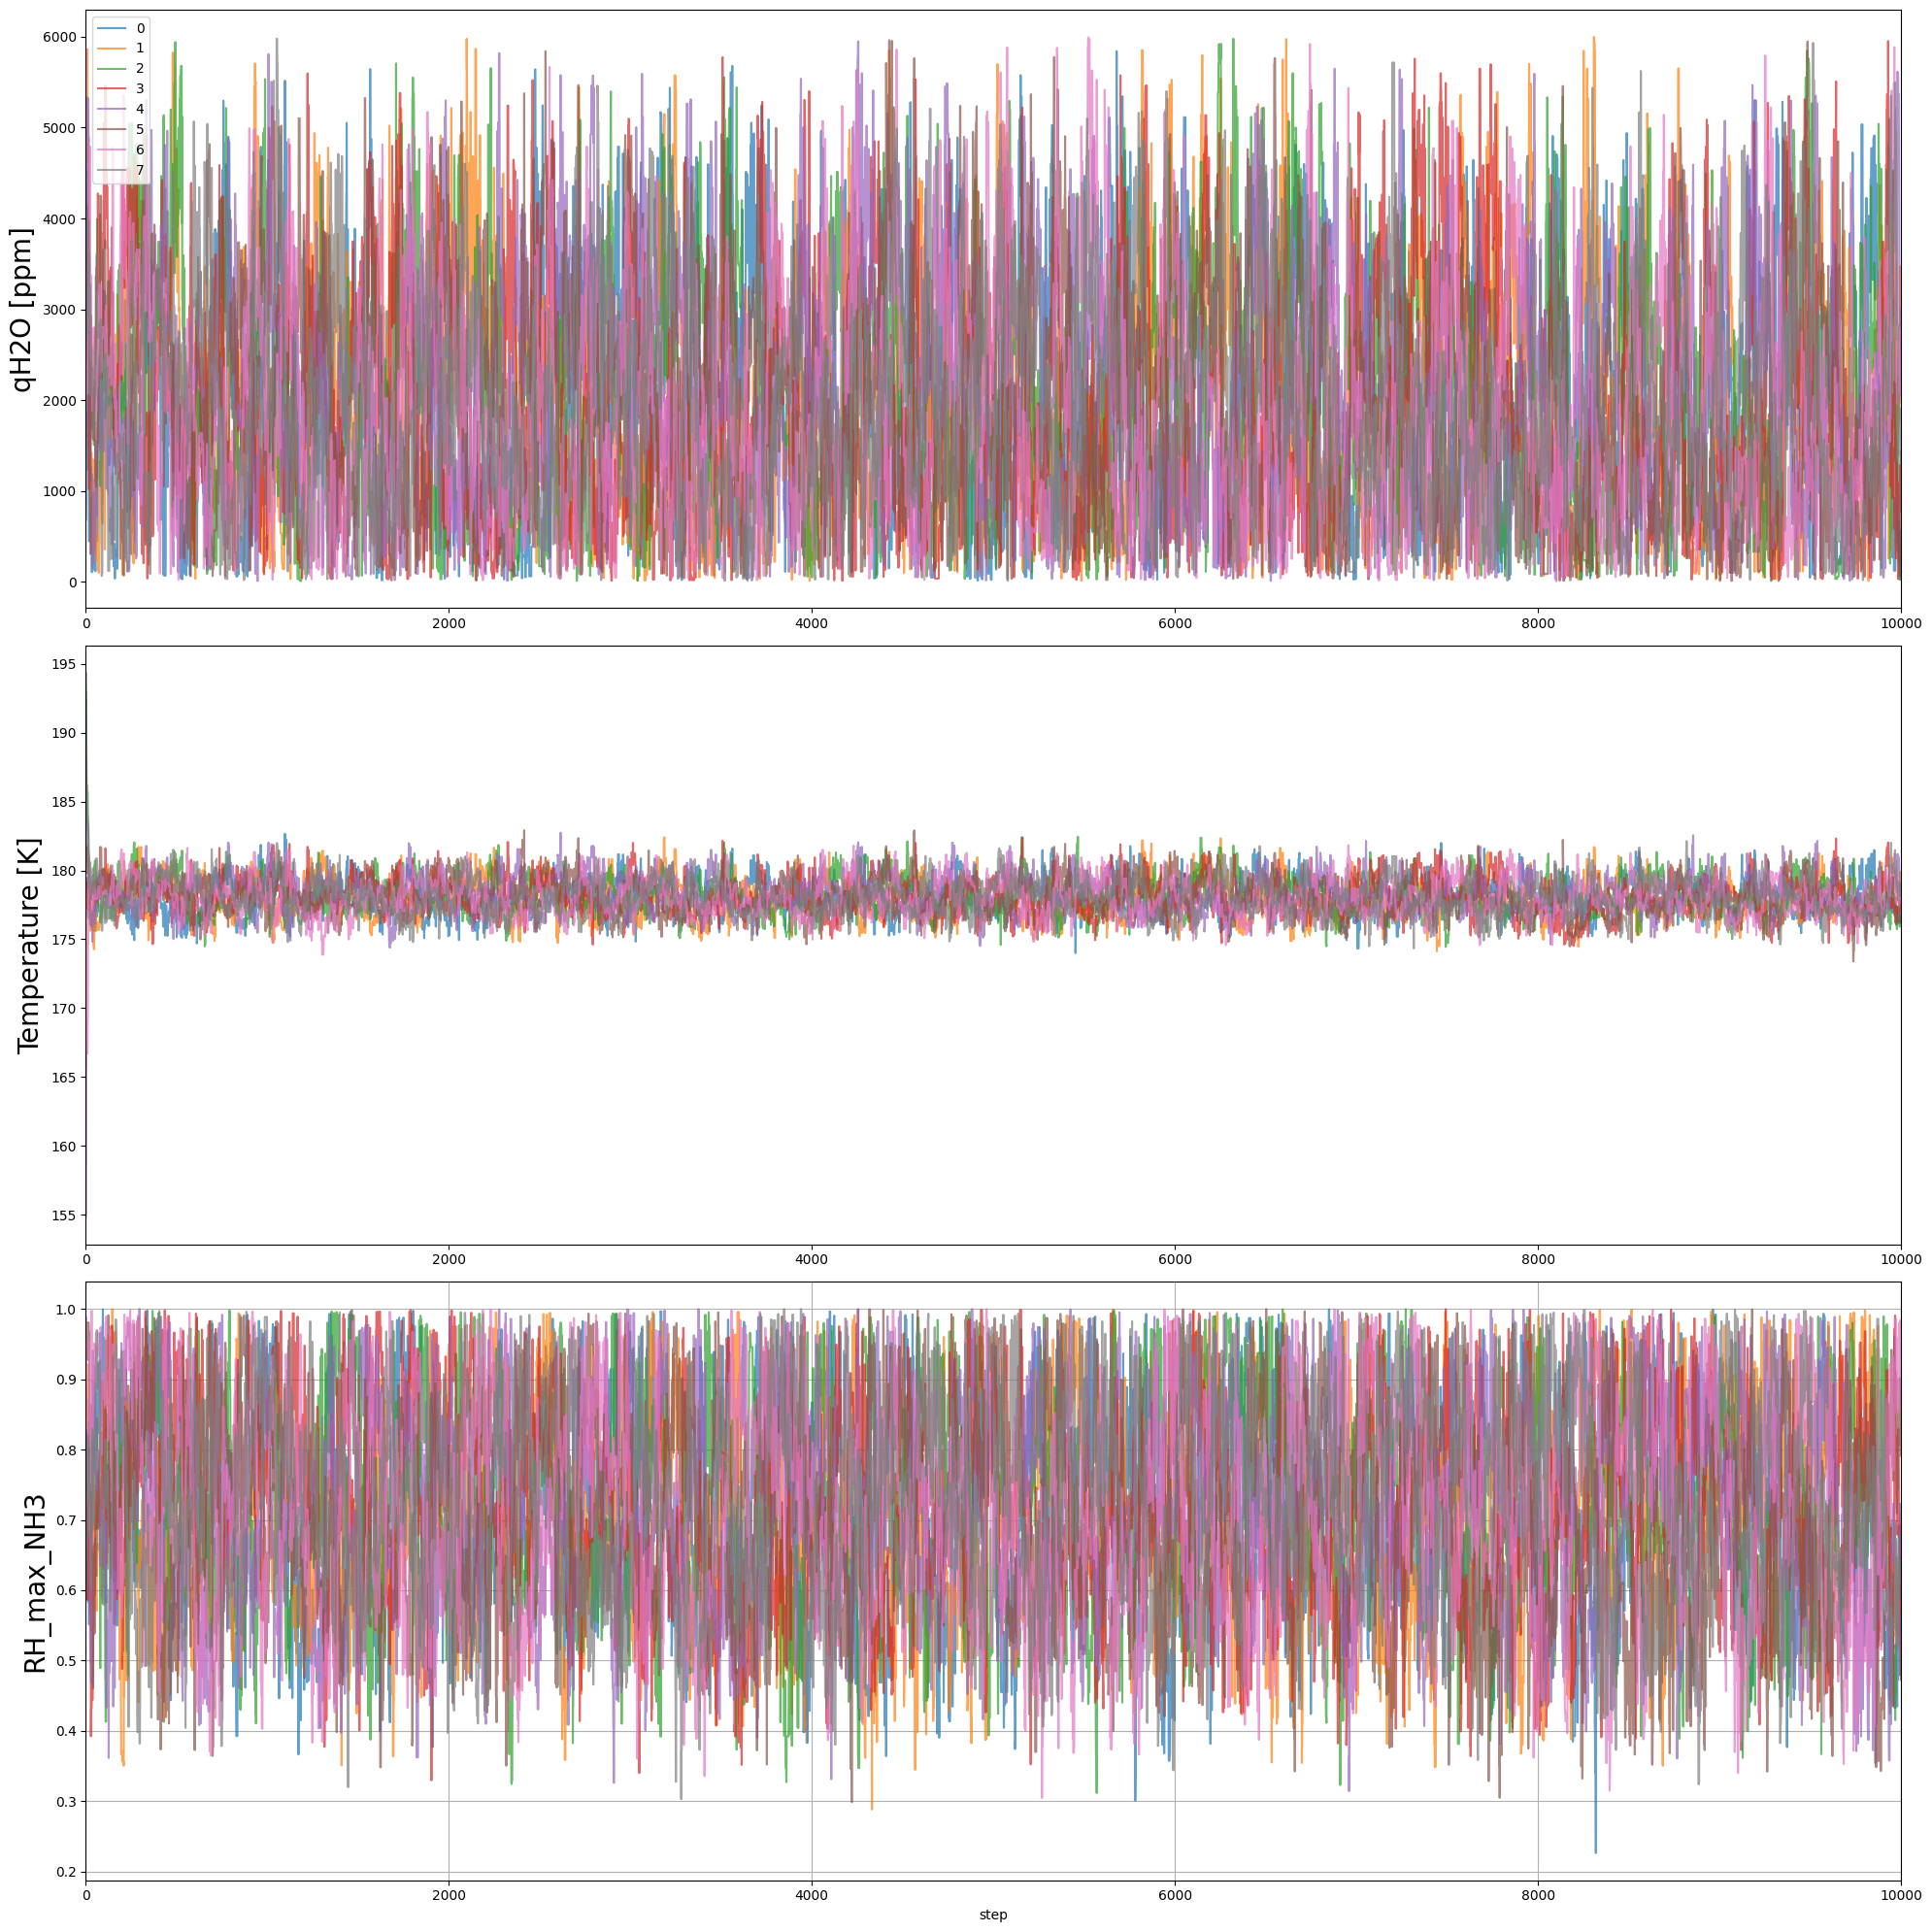

In [3]:
fig, ax = plt.subplots(ndim, 1, figsize=(20, 20))
for i in range(ndim):
    for iw in range(8):
        ax[i].plot(range(nstep), chain[:, iw, i],label=iw, alpha=0.7)
        ax[i].set_ylabel(labels[i],fontsize=20)
        ax[i].set_xlim([0, nstep])
ax[0].legend()
ax[ndim-1].set_xlabel("step")
plt.tight_layout()
plt.grid(True)
plt.show()

In [4]:
import corner

flattened_chain = chain[3000:,:,:].reshape(-1,3)
flattened_chain[:, 0]=flattened_chain[:, 0]*1E-3

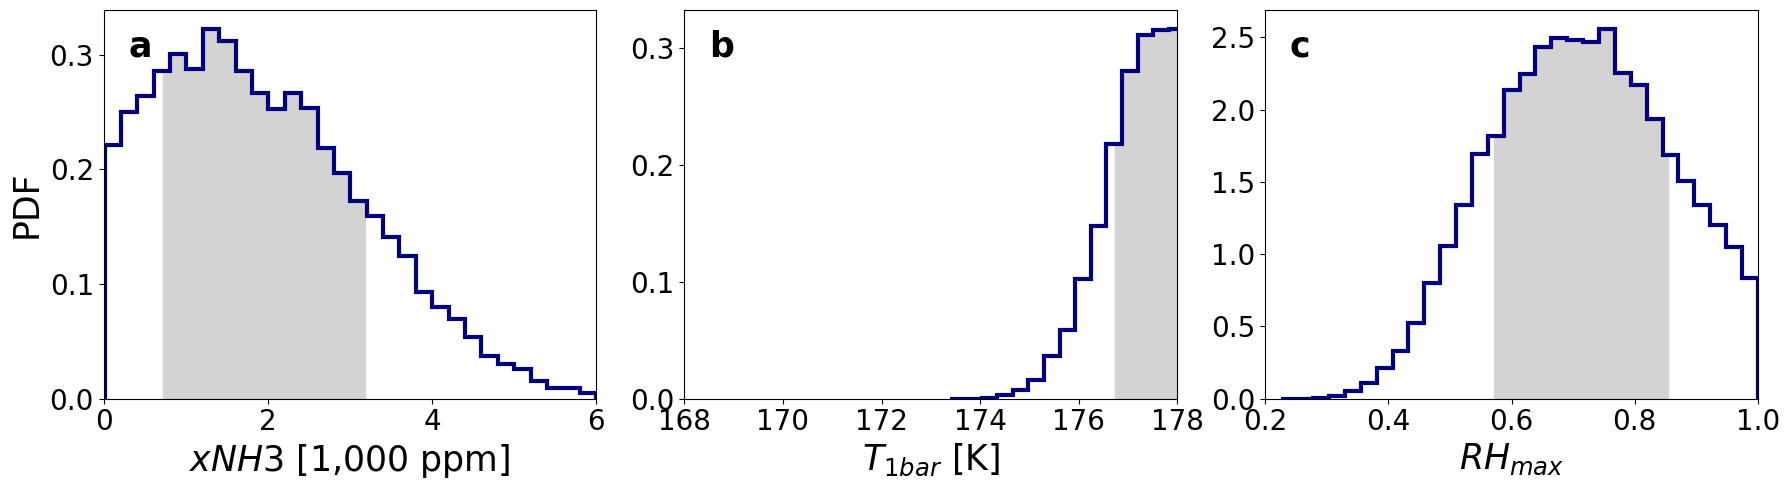

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# labels=[r"$xNH3$ [ppm]", r"$T_{1bar}$ [K]", r"$RH_{max}$",r"$\Delta\frac{dlnNH3}{dlnP}$",r"$P_{max}$ [bar]"]
labels=[r"$xNH3$ [1,000 ppm]", r"$T_{1bar}$ [K]", r"$RH_{max}$",r"$\Delta\Gamma$",r"$P_{max}$ [bar]"]

# Assuming flattened_chain and labels are already defined
fig, ax = plt.subplots(1,3, figsize=(18, 5))

ax = ax.flatten()
# ax[5].axis('off')

minx = [0, 168, 0.2, -0.4, 1]
maxx = [6, 178, 1, 0.2, 9]

for i in range(3):
    ax[i].hist(flattened_chain[:, i], bins=30, color="Navy", alpha=1, histtype='step', linewidth=3, density=True)
    ax[i].tick_params(axis='both', labelsize=20)
    ax[i].set_xlabel(labels[i], fontsize=25)
    # ax[0].set_xticks([330,360,390,420])
    # ax[0].set_yticks([0.,0.01,0.02,0.03])
    ax[0].set_ylabel("PDF", fontsize=25)
    # ax[3].set_ylabel("PDF", fontsize=25)
    ax[i].set_xlim(minx[i], maxx[i])

    counts, bins = np.histogram(flattened_chain[:, i], bins=30)

    # Find the peak value (the bin with the maximum count)
    peak_index = np.argmax(counts)
    peak_value = (bins[peak_index] + bins[peak_index + 1]) / 2.

    means = np.mean(flattened_chain[:, i])
    stdev = np.std(flattened_chain[:, i])
    # if i == 2:
    #     means = peak_value

    # ax[i].axvline(means,color="navy",linestyle="--")    
    # ax[i].axvline(means-stdev,color="b",linestyle="--")    
    # ax[i].axvline(means+stdev,color="b",linestyle="--")    

    # Calculate histogram data
    counts, bin_edges = np.histogram(flattened_chain[:, i], bins=30, density=True)
  
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means - stdev) and  bin_edges[ii+1]>=(means - stdev):
            ax[i].fill_between([means - stdev,bin_edges[ii+1]], 0,[counts[ii],counts[ii]],
                       color='lightgray', alpha=1., edgecolor="lightgray")
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(means + stdev) and  bin_edges[ii+1]>=(means + stdev):
            ax[i].fill_between([bin_edges[ii],means + stdev], 0,[counts[ii],counts[ii]],
                       color='lightgray', alpha=1., edgecolor="lightgray")
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(means - stdev) and  bin_edges[ii+1]<=(means + stdev):
            ax[i].fill_between([bin_edges[ii],bin_edges[ii+1]], 0,[counts[ii],counts[ii]],
                       color='lightgray', alpha=1., edgecolor="lightgray")
                
    ax[i].text(0.05, 0.95, ['a','b','c','d','e'][i], transform=ax[i].transAxes, 
                    fontsize=25, fontweight='bold', va='top', ha='left')
# Show the plot
plt.tight_layout()
plt.show()



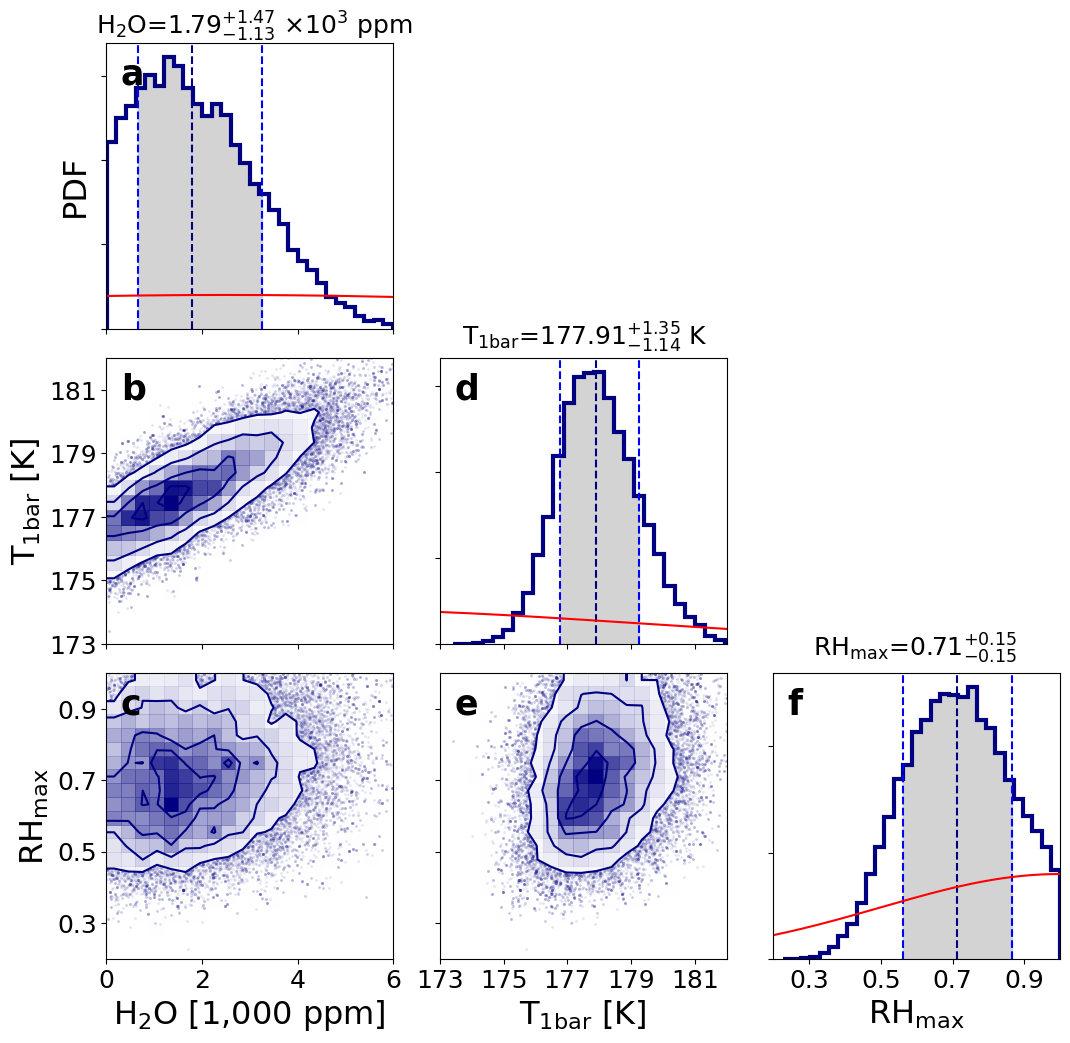

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import corner

# labels=[r"$xNH3$ [ppm]", r"$T_{1bar}$ [K]", r"$RH_{max}$",r"$\Delta\frac{dlnNH3}{dlnP}$",r"$P_{max}$ [bar]"]
labels=[r"H$_2$O", r"T$_\text{1bar}$", r"RH$_\text{max}$"]
units=[" [1,000 ppm]", " [K]",""]
unit=[r"$\times 10^3$ ppm", "K",""]

fig, ax = plt.subplots(3,3 , figsize=(18*0.6, 17*0.6))



minx = [0, 173, 0.2]
maxx = [6, 182, 1]

ticks=[[0,2,4,6],
       [173,175,177, 179, 181],
       [0.3,0.5,0.7,0.9]
       ]

ip=0
for i in range(3):
    for j in range(i,3):
        if i!=j:
            ax[i,j].axis('off')
            corner.hist2d(flattened_chain[:, i], flattened_chain[:, j], ax=ax[j, i], color="navy")

        ip+=1
        ax[j,i].text(0.05, 0.95, chr(96+ip), transform=ax[j,i].transAxes, fontsize=25, fontweight='bold', va='top', ha='left')

        ax[j,i].tick_params(axis='x', labelsize=18)
        ax[j,i].tick_params(axis='y', labelsize=18)

        ax[j,i].set_xlim(minx[i],maxx[i])
        if i!=j:
            ax[j,i].set_ylim(minx[j],maxx[j])

        if j==2:
            ax[j,i].set_xlabel(labels[i]+units[i], fontsize=23)
        else:
            ax[j,i].set_xlabel("")
        if i==0 and i!=j:
            ax[j,i].set_ylabel(labels[j]+units[j], fontsize=23)
        else:
            ax[j,i].set_ylabel("")            

        if i!=j:
            ax[j,i].set_yticks(ticks[j])
        ax[j,i].set_xticks(ticks[i])    

        ax[j,i].set_xticklabels([])
        ax[j,i].set_yticklabels([])
        if j==2:
            ax[j,i].set_xticklabels(ticks[i])
        if i==0 and i!=j:
            ax[j,i].set_yticklabels(ticks[j])
    ax[0,0].set_ylabel("PDF", fontsize=23)

    ## PDF for diagnal subplots
    ax[i,i].hist(flattened_chain[:, i], bins=30, color="Navy", alpha=1, histtype='step', linewidth=3, density=True)

    mmy = np.percentile(flattened_chain[:, i], 50)
    lowery = np.percentile(flattened_chain[:, i], 16)
    uppery = np.percentile(flattened_chain[:, i], 84)
    ## reflines
    ax[i,i].axvline(mmy,color="navy",linestyle="--")    
    ax[i,i].axvline(lowery,color="b",linestyle="--")    
    ax[i,i].axvline(uppery,color="b",linestyle="--")    

    # Plot prior distribution
    mean, stddev = [(2.5, 10), (169, 10), (1.0,0.5)][i]
    x = np.linspace(minx[i], maxx[i], 300)
    prior = norm.pdf(x, mean, stddev)
    ax[i,i].plot(x, prior, color="red", linestyle="-")

    ## show posteriors over head
    teex=fr"{labels[i]}=${mmy:.2f}_{{{lowery-mmy:.2f}}}^{{+{uppery-mmy:.2f}}}$ {unit[i]}"
    fig.text(0.24+i*0.92/3., 1.018-(i*0.183*5/3.), teex, ha='center', va='top', fontsize=18)


    # Calculate histogram data
    counts, bin_edges = np.histogram(flattened_chain[:, i], bins=30, density=True)

    for ii in range(len(counts)):
        if bin_edges[ii]<=(lowery) and  bin_edges[ii+1]>=(lowery):
            ax[i,i].fill_between([lowery,bin_edges[ii+1]], 0,[counts[ii],counts[ii]],
                    color='lightgray', alpha=1., edgecolor="lightgray")
        
    for ii in range(len(counts)):
        if bin_edges[ii]<=(uppery) and  bin_edges[ii+1]>=(uppery):
            ax[i,i].fill_between([bin_edges[ii],uppery], 0,[counts[ii],counts[ii]],
                    color='lightgray', alpha=1., edgecolor="lightgray")
        
    for ii in range(len(counts)):
        if bin_edges[ii]>=(lowery) and  bin_edges[ii+1]<=(uppery):
            ax[i,i].fill_between([bin_edges[ii],bin_edges[ii+1]], 0,[counts[ii],counts[ii]],
                    color='lightgray', alpha=1., edgecolor="lightgray")

# Show the plot
plt.tight_layout()
plt.savefig("Ext_MCMC_moist_corners.pdf", dpi=300,bbox_inches='tight')